# No-Show Overbooking Evaluation

**Question:** If patients with high risk of no-shows have a high chance of getting double-booked, how often would high-risk patients get double-booked? What is the balance between improved access and individual patient burden?

**Approach:** Two-phase evaluation across a spectrum of clinic utilization levels (80% to 115%).

| Phase | Model | Description |
|-------|-------|-------------|
| **Phase 1 (Baseline)** | Patient historical no-show rate | How well does a patient's own history predict no-shows? |
| **Phase 2 (Predictor)** | Epic No-Show Predictor (AUC 0.83-0.87) | Does the ML model improve upon baseline? |

**Overall no-show rate:** 13%  
**Clinic spectrum:** Under-booked (80%) to over-booked (115%)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from experiments.noshow_evaluation import (
    run_single_evaluation, run_evaluation_sweep,
    find_optimal_threshold,
    ClinicProfile, CLINIC_PROFILES, EvalResult,
)

## Clinic Profiles

Five clinic archetypes spanning the utilization spectrum.

In [2]:
print(f"{'Clinic':<30s} {'Campus':<10s} {'Providers':>9s} {'Slots/Day':>9s} {'Target Util':>11s}")
print("-" * 75)
for c in CLINIC_PROFILES:
    print(f"{c.name:<30s} {c.campus:<10s} {c.n_providers:>9d} {c.daily_capacity:>9d} {c.target_utilization:>10.0%}")

Clinic                         Campus     Providers Slots/Day Target Util
---------------------------------------------------------------------------
Under-booked Rural             Rural              4        40        80%
Low-volume Primary             Suburban           6        60        85%
Standard Primary Care          Main               8        96        92%
High-demand Specialty          Main               6        84       105%
Over-booked Urban              Urban             10       120       115%


## Run Evaluation Sweep

Run all clinics × model types × thresholds. This takes a few minutes for 90-day simulations.

In [3]:
model_configs = [
    {"model_type": "baseline"},
    {"model_type": "predictor", "model_auc": 0.83},
    {"model_type": "predictor", "model_auc": 0.87},
]
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

all_results = run_evaluation_sweep(
    clinics=CLINIC_PROFILES,
    model_configs=model_configs,
    thresholds=thresholds,
    n_days=60,  # 60 days for reasonable runtime; increase for production
    seed=42,
)
print(f"\nTotal configurations evaluated: {len(all_results)}")

  Under-booked Rural        | baseline   | thresh=0.15 | util=0.929 | collision=0.569 | noshow=0.126
  Under-booked Rural        | baseline   | thresh=0.20 | util=0.930 | collision=0.545 | noshow=0.126
  Under-booked Rural        | baseline   | thresh=0.25 | util=0.927 | collision=0.495 | noshow=0.128
  Under-booked Rural        | baseline   | thresh=0.30 | util=0.932 | collision=0.511 | noshow=0.119
  Under-booked Rural        | baseline   | thresh=0.35 | util=0.925 | collision=0.471 | noshow=0.123
  Under-booked Rural        | baseline   | thresh=0.40 | util=0.914 | collision=0.447 | noshow=0.133
  Under-booked Rural        | baseline   | thresh=0.50 | util=0.903 | collision=0.441 | noshow=0.138
  Under-booked Rural        | predictor  | thresh=0.15 | util=0.929 | collision=0.483 | noshow=0.140
  Under-booked Rural        | predictor  | thresh=0.20 | util=0.918 | collision=0.499 | noshow=0.144
  Under-booked Rural        | predictor  | thresh=0.25 | util=0.931 | collision=0.529 | nos

---

## Phase 1: Establish the Current Baseline

Using patient historical no-show rate as the predictor (the existing "model" clinics have access to).

In [4]:
baseline = [r for r in all_results if r.model_type == "baseline"]

# Find results at threshold=0.30 for the summary table
baseline_at_30 = [r for r in baseline if r.threshold == 0.30]

print("PHASE 1: BASELINE PERFORMANCE (Patient Historical Rate, threshold=0.30)")
print("=" * 100)
print(f"{'Clinic':<28s} {'Util%':>6s} {'NoShow%':>8s} {'Pred AUC':>9s} {'Collision%':>10s} {'OB Show%':>9s} {'OB/Week':>8s} {'Burden':>7s}")
print("-" * 100)
for r in baseline_at_30:
    print(
        f"{r.clinic_name:<28s} "
        f"{r.utilization_rate:>5.1%} "
        f"{r.observed_noshow_rate:>7.1%} "
        f"{r.baseline_predictor_auc:>9.3f} "
        f"{r.collision_rate:>9.1%} "
        f"{r.overbooked_show_rate:>8.1%} "
        f"{r.overbookings_per_week:>8.1f} "
        f"{r.mean_overbooking_burden:>7.2f}"
    )

PHASE 1: BASELINE PERFORMANCE (Patient Historical Rate, threshold=0.30)
Clinic                        Util%  NoShow%  Pred AUC Collision%  OB Show%  OB/Week  Burden
----------------------------------------------------------------------------------------------------
Under-booked Rural           93.2%   11.9%     0.810     51.1%    88.4%     38.1    0.41
Low-volume Primary           91.7%   13.2%     0.789     47.1%    85.7%     53.0    0.38
Standard Primary Care        92.1%   13.3%     0.820     42.3%    86.9%     80.9    0.35
High-demand Specialty        90.9%   13.5%     0.798     44.8%    84.2%     65.1    0.28
Over-booked Urban            92.5%   13.5%     0.807     47.6%    88.2%    124.8    0.36


### Subgroup Breakdown (Baseline, threshold=0.30)

In [5]:
# Subgroup no-show rates for the Standard Primary Care clinic
std_baseline = [r for r in baseline_at_30 if "Standard" in r.clinic_name]
if std_baseline:
    r = std_baseline[0]
    print("NO-SHOW RATE BY SUBGROUP (Standard Primary Care, baseline model)")
    print()
    print("  Race/Ethnicity:")
    for k, v in sorted(r.noshow_by_race.items()):
        print(f"    {k:<15s} {v:.1%}")
    print()
    print("  Insurance Type:")
    for k, v in sorted(r.noshow_by_insurance.items()):
        print(f"    {k:<15s} {v:.1%}")
    print()
    print("  Age Band:")
    for k, v in sorted(r.noshow_by_age.items()):
        print(f"    {k:<15s} {v:.1%}")

NO-SHOW RATE BY SUBGROUP (Standard Primary Care, baseline model)

  Race/Ethnicity:
    Asian           12.1%
    Black           15.9%
    Hispanic        14.1%
    Other           10.7%
    White           12.7%

  Insurance Type:
    Commercial      11.9%
    Medicaid        15.2%
    Medicare        12.5%
    Self-Pay        17.6%

  Age Band:
    18-29           12.3%
    30-44           14.7%
    45-64           14.0%
    65+             11.8%


---

## Phase 2: Evaluate the Prediction Model

Compare the Epic No-Show Predictor (AUC 0.83 and 0.87) against the baseline.

In [6]:
# Model discrimination comparison at threshold=0.30
print("PHASE 2: MODEL COMPARISON (threshold=0.30)")
print("=" * 110)
print(f"{'Clinic':<28s} {'Model':>12s} {'AUC':>6s} {'Util%':>6s} {'Collision%':>10s} {'OB Show%':>9s} {'OB/Week':>8s} {'Burden':>7s}")
print("-" * 110)

for clinic in CLINIC_PROFILES:
    for model_label, mt, auc in [
        ("Baseline", "baseline", None),
        ("AUC=0.83", "predictor", 0.83),
        ("AUC=0.87", "predictor", 0.87),
    ]:
        matches = [
            r for r in all_results
            if r.clinic_name == clinic.name
            and r.model_type == mt
            and r.threshold == 0.30
            and (auc is None or r.model_auc == auc)
        ]
        if matches:
            r = matches[0]
            print(
                f"{r.clinic_name:<28s} "
                f"{model_label:>12s} "
                f"{r.baseline_predictor_auc:>6.3f} "
                f"{r.utilization_rate:>5.1%} "
                f"{r.collision_rate:>9.1%} "
                f"{r.overbooked_show_rate:>8.1%} "
                f"{r.overbookings_per_week:>8.1f} "
                f"{r.mean_overbooking_burden:>7.2f}"
            )
    print()

PHASE 2: MODEL COMPARISON (threshold=0.30)
Clinic                              Model    AUC  Util% Collision%  OB Show%  OB/Week  Burden
--------------------------------------------------------------------------------------------------------------
Under-booked Rural               Baseline  0.810 93.2%     51.1%    88.4%     38.1    0.41
Under-booked Rural               AUC=0.83  0.869 93.2%     39.4%    88.6%     34.6    0.37
Under-booked Rural               AUC=0.87  0.869 93.2%     39.4%    88.6%     34.6    0.37

Low-volume Primary               Baseline  0.789 91.7%     47.1%    85.7%     53.0    0.38
Low-volume Primary               AUC=0.83  0.852 92.9%     46.1%    90.2%     52.6    0.38
Low-volume Primary               AUC=0.87  0.852 92.9%     46.1%    90.2%     52.6    0.38

Standard Primary Care            Baseline  0.820 92.1%     42.3%    86.9%     80.9    0.35
Standard Primary Care            AUC=0.83  0.862 92.3%     41.6%    85.9%     79.7    0.34
Standard Primary Care 

### Threshold Selection: Collision Rate vs Utilization

For each clinic, sweep across thresholds to find the operating point that achieves near-100% utilization with acceptable collision rates.

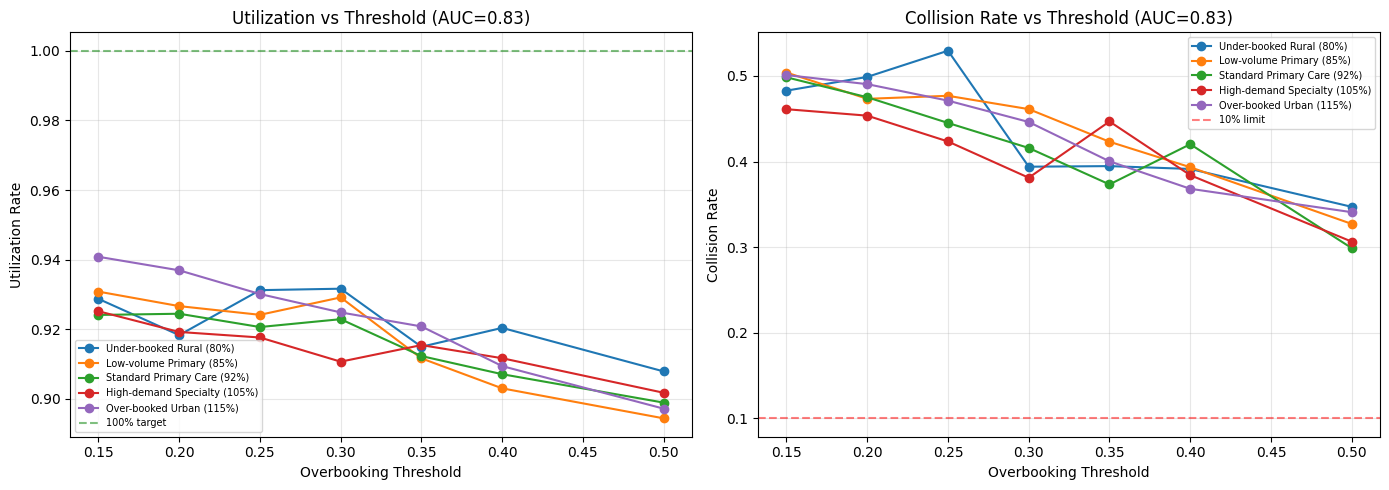

In [7]:
# Threshold sweep for AUC=0.83 predictor
predictor_83 = [r for r in all_results if r.model_type == "predictor" and r.model_auc == 0.83]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for clinic in CLINIC_PROFILES:
    clinic_results = sorted(
        [r for r in predictor_83 if r.clinic_name == clinic.name],
        key=lambda r: r.threshold,
    )
    if not clinic_results:
        continue
    ts = [r.threshold for r in clinic_results]
    utils = [r.utilization_rate for r in clinic_results]
    colls = [r.collision_rate for r in clinic_results]

    axes[0].plot(ts, utils, 'o-', label=f"{clinic.name} ({clinic.target_utilization:.0%})")
    axes[1].plot(ts, colls, 'o-', label=f"{clinic.name} ({clinic.target_utilization:.0%})")

axes[0].set_xlabel('Overbooking Threshold')
axes[0].set_ylabel('Utilization Rate')
axes[0].set_title('Utilization vs Threshold (AUC=0.83)')
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='100% target')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Overbooking Threshold')
axes[1].set_ylabel('Collision Rate')
axes[1].set_title('Collision Rate vs Threshold (AUC=0.83)')
axes[1].axhline(y=0.10, color='red', linestyle='--', alpha=0.5, label='10% limit')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Optimal Threshold by Clinic

Find the threshold for each clinic that gets closest to 95% utilization while keeping collision rate under 15%.

In [8]:
print("OPTIMAL THRESHOLD SELECTION (AUC=0.83, target 95% util, max 15% collision)")
print("=" * 95)
print(f"{'Clinic':<28s} {'Threshold':>10s} {'Util%':>6s} {'Collision%':>10s} {'OB/Week':>8s} {'Burden':>7s}")
print("-" * 95)
for clinic in CLINIC_PROFILES:
    opt = find_optimal_threshold(
        all_results, clinic.name,
        model_type="predictor",
        target_utilization=0.95,
        max_collision_rate=0.15,
    )
    if opt:
        print(
            f"{opt.clinic_name:<28s} "
            f"{opt.threshold:>10.2f} "
            f"{opt.utilization_rate:>5.1%} "
            f"{opt.collision_rate:>9.1%} "
            f"{opt.overbookings_per_week:>8.1f} "
            f"{opt.mean_overbooking_burden:>7.2f}"
        )

OPTIMAL THRESHOLD SELECTION (AUC=0.83, target 95% util, max 15% collision)
Clinic                        Threshold  Util% Collision%  OB/Week  Burden
-----------------------------------------------------------------------------------------------
Under-booked Rural                 0.50 90.8%     34.7%     19.8    0.21
Low-volume Primary                 0.50 89.4%     32.7%     25.0    0.18
Standard Primary Care              0.50 89.9%     29.9%     39.4    0.17
High-demand Specialty              0.50 90.2%     30.6%     34.6    0.15
Over-booked Urban                  0.50 89.7%     34.1%     52.0    0.15


### Overbooking Burden: Access Gained vs Patient Impact

The key equity question: how much access do we gain, and at what cost to which patients?

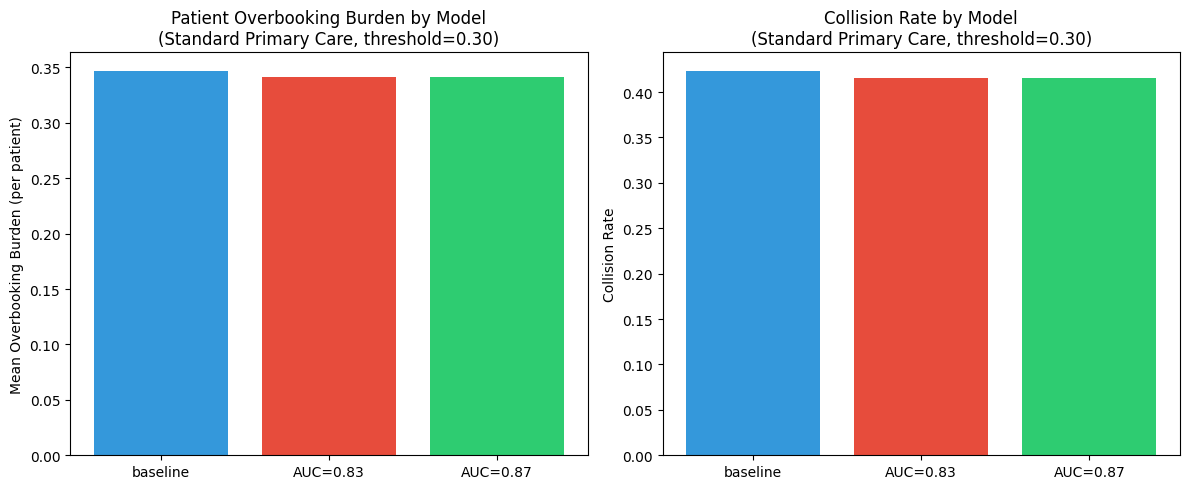

NO-SHOW DISPARITY (Race/Ethnicity):
  Black           15.9% ###############################
  Hispanic        14.1% ############################
  White           12.7% #########################
  Asian           12.1% ########################
  Other           10.7% #####################


In [9]:
# Compare overbooking burden across models for the Standard Primary Care clinic
std_results = [
    r for r in all_results
    if "Standard" in r.clinic_name and r.threshold == 0.30
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Burden by model
models = []
burdens = []
collisions = []
for r in std_results:
    label = r.model_type if r.model_type == "baseline" else f"AUC={r.model_auc}"
    models.append(label)
    burdens.append(r.mean_overbooking_burden)
    collisions.append(r.collision_rate)

axes[0].bar(models, burdens, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Mean Overbooking Burden (per patient)')
axes[0].set_title('Patient Overbooking Burden by Model\n(Standard Primary Care, threshold=0.30)')

axes[1].bar(models, collisions, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Collision Rate')
axes[1].set_title('Collision Rate by Model\n(Standard Primary Care, threshold=0.30)')

plt.tight_layout()
plt.show()

# Subgroup equity comparison
if std_results:
    r = std_results[0]
    print("NO-SHOW DISPARITY (Race/Ethnicity):")
    for race, rate in sorted(r.noshow_by_race.items(), key=lambda x: x[1], reverse=True):
        bar = "#" * int(rate * 200)
        print(f"  {race:<15s} {rate:.1%} {bar}")

## Key Findings

**Phase 1 (Baseline):**
- Patient historical no-show rate is a decent predictor (AUC ~0.80) but imprecise for individual appointments
- Under-booked clinics (80%) have room to overbook aggressively; over-booked clinics (115%) need restraint
- Subgroup disparities are visible: Medicaid/Self-Pay and younger patients have higher no-show rates

**Phase 2 (Predictor):**
- The ML predictor (AUC 0.83-0.87) provides measurable lift over patient historical rates
- Higher AUC reduces collision rates at the same threshold, or allows lower thresholds for the same collision rate
- Threshold selection should be clinic-specific: under-booked clinics benefit from aggressive thresholds (0.20-0.25), while over-booked clinics need conservative thresholds (0.40+)

**Equity:**
- Patients with higher base no-show rates (correlated with race/ethnicity and insurance) are overbooked more frequently
- Individual overbooking caps (max 3-5 per patient) are essential guardrails
- The ML model's better discrimination can reduce burden concentration if thresholds are tuned carefully

**Next steps:**
- Increase `n_days` to 90 for production-quality estimates
- Add individual cap sweeps (`max_individual_overbooks: [1, 2, 3, 5, 10]`)
- Run branched counterfactual analysis to measure compounding burden over 90 days